## Imports & Paths

In [1]:


from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

INPUT_DIR = Path(".")
OUT_DIR = INPUT_DIR / "S18_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VARIANTS = ["FULL", "CLINICAL", "BIOMARKERS"]

CONFIG = {
    "variants": VARIANTS,
    "input_file": "S15_feature_reliability_table.csv",
}

with open(OUT_DIR / "S18_config_snapshot.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

## Load input

In [2]:
feature_table = pd.read_csv(INPUT_DIR / "S15_feature_reliability_table.csv")
feature_table.head()

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.0,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.0,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.0,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.0,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.0,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL


## Identify unresolved rows

In [3]:

unresolved = feature_table[feature_table["feature_class"] == "UNRESOLVED"].copy()
unresolved

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class
9,BIOMARKERS,RF_SHALLOW,cholesterol_calkowity_tc,-0.005921,0.000000,10.0,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.0,0.922596,0.461298,0.0,1.00000,0.549557,0.774779,0.153766,0.000000,10.0,0.000000,UNRESOLVED
11,CLINICAL,RF_SHALLOW,waga_kg,0.003746,0.003746,2.0,NaN,NaN,NaN,NaN,0.791946,0.968750,NaN,0.0,0.213781,0.591266,0.0,0.45098,0.113102,0.282041,0.461071,0.884798,2.0,0.791946,UNRESOLVED
15,CLINICAL,RF_SHALLOW,zaburzenia_rytmu,0.001905,0.001905,3.0,NaN,NaN,NaN,NaN,0.402685,0.937500,NaN,0.0,0.613759,0.775630,0.0,0.45098,0.113102,0.282041,0.392771,0.682682,6.0,0.402685,UNRESOLVED
19,CLINICAL,RF_SHALLOW,nadcisnienie_tetnicze_nt,0.001556,0.001556,4.0,NaN,NaN,NaN,NaN,0.328859,0.906250,NaN,0.0,0.689617,0.797933,0.0,0.45098,0.113102,0.282041,0.375598,0.631860,10.0,0.328859,UNRESOLVED
31,CLINICAL,RF_SHALLOW,noac,-0.001143,0.000000,8.0,NaN,NaN,NaN,NaN,0.000000,0.781250,NaN,0.0,0.972471,0.876860,0.0,0.45098,0.113102,0.282041,0.292287,0.385321,19.0,0.000000,UNRESOLVED
33,CLINICAL,RF_SHALLOW,nabyta_wada_serca,-0.001333,0.000000,9.0,NaN,NaN,NaN,NaN,0.000000,0.750000,NaN,0.0,0.972471,0.861235,0.0,0.45098,0.113102,0.282041,0.287078,0.369908,21.0,0.000000,UNRESOLVED
34,CLINICAL,RF_SHALLOW,wzrost_cm,-0.002127,0.000000,10.0,NaN,NaN,NaN,NaN,0.000000,0.718750,NaN,0.0,0.972471,0.845610,0.0,0.45098,0.113102,0.282041,0.281870,0.354496,22.0,0.000000,UNRESOLVED
35,CLINICAL,RF_SHALLOW,cad,-0.003460,0.000000,13.0,NaN,NaN,NaN,NaN,0.000000,0.625000,NaN,0.0,0.972471,0.798735,0.0,0.45098,0.113102,0.282041,0.266245,0.308257,23.0,0.000000,UNRESOLVED
36,CLINICAL,RF_SHALLOW,hba1c,-0.003556,0.000000,14.0,NaN,NaN,NaN,NaN,0.000000,0.593750,NaN,0.0,0.972471,0.783110,0.0,0.45098,0.113102,0.282041,0.261037,0.292844,24.0,0.000000,UNRESOLVED
37,CLINICAL,RF_SHALLOW,petlowy,-0.004381,0.000000,15.0,NaN,NaN,NaN,NaN,0.000000,0.562500,NaN,0.0,0.972471,0.767485,0.0,0.45098,0.113102,0.282041,0.255828,0.277431,25.0,0.000000,UNRESOLVED


## Helper: determine primary unresolved reason

In [4]:


def unresolved_reason(row):
    reasons = []

    if pd.isna(row.get("importance_score")):
        reasons.append("missing_importance_score")
    if pd.isna(row.get("ablation_score")):
        reasons.append("missing_ablation_score")
    if pd.isna(row.get("stability_score")):
        reasons.append("missing_stability_score")

    if pd.isna(row.get("importance_mean_raw")):
        reasons.append("missing_raw_importance")
    if pd.isna(row.get("ablation_delta_auc_mean_raw")):
        reasons.append("missing_raw_ablation")

    if pd.isna(row.get("cross_variant_consistency")):
        reasons.append("missing_cross_variant_consistency")

    if len(reasons) == 0:
        return "no_missing_components_detected"
    if len(reasons) == 1:
        return reasons[0]
    return "multiple_missing_components"


def unresolved_reason_detail(row):
    details = []

    for col in [
        "importance_mean_raw",
        "importance_mean_nonneg",
        "importance_score",
        "importance_rank",
        "ablation_delta_auc_mean_raw",
        "ablation_delta_auc_mean",
        "ablation_score",
        "cross_variant_consistency",
        "stability_score",
        "FRS_raw",
        "FRS",
    ]:
        if pd.isna(row.get(col)):
            details.append(col)

    return ";".join(details) if details else "none"

## Build unresolved audit table

In [5]:


if unresolved.empty:
    unresolved_audit = pd.DataFrame(columns=[
        "variant", "feature", "winner_model",
        "unresolved_reason", "unresolved_detail",
        "importance_mean_raw", "ablation_delta_auc_mean_raw",
        "cross_variant_consistency", "importance_score", "ablation_score", "stability_score", "FRS"
    ])
else:
    unresolved_audit = unresolved.copy()
    unresolved_audit["unresolved_reason"] = unresolved_audit.apply(unresolved_reason, axis=1)
    unresolved_audit["unresolved_detail"] = unresolved_audit.apply(unresolved_reason_detail, axis=1)

    unresolved_audit = unresolved_audit[[
        "variant", "feature", "winner_model",
        "unresolved_reason", "unresolved_detail",
        "importance_mean_raw", "ablation_delta_auc_mean_raw",
        "cross_variant_consistency", "importance_score", "ablation_score", "stability_score", "FRS"
    ]].sort_values(["variant", "unresolved_reason", "feature"]).reset_index(drop=True)

unresolved_audit.to_csv(OUT_DIR / "S18_unresolved_feature_audit.csv", index=False)
unresolved_audit.head(30)

,variant,feature,winner_model,unresolved_reason,unresolved_detail,importance_mean_raw,ablation_delta_auc_mean_raw,cross_variant_consistency,importance_score,ablation_score,stability_score,FRS
0,BIOMARKERS,cholesterol_calkowity_tc,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.005921,NaN,0.922596,0.000000,NaN,0.461298,0.000000
1,CLINICAL,cad,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.003460,NaN,0.972471,0.000000,NaN,0.798735,0.308257
2,CLINICAL,cukrzyca_dm,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.007714,NaN,0.972471,0.000000,NaN,0.704985,0.215780
3,CLINICAL,czy_pali,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.009492,NaN,0.972471,0.000000,NaN,0.673735,0.184954
4,CLINICAL,hb_przyjecie,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.042857,NaN,0.972471,0.000000,NaN,0.486235,0.000000
5,CLINICAL,hba1c,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.003556,NaN,0.972471,0.000000,NaN,0.783110,0.292844
6,CLINICAL,ht_przyjecie,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.030254,NaN,0.972471,0.000000,NaN,0.517485,0.030826
7,CLINICAL,klop,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.023238,NaN,0.972471,0.000000,NaN,0.533110,0.046239
8,CLINICAL,kwas_moczowy,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.017175,NaN,0.972471,0.000000,NaN,0.595610,0.107890
9,CLINICAL,mpv_przyjecie,RF_SHALLOW,multiple_missing_components,ablation_delta_auc_mean_raw;ablation_delta_auc...,-0.005016,NaN,0.972471,0.000000,NaN,0.751860,0.262018


## Summary by variant and reason

In [6]:


unresolved_reason_summary = (
    unresolved_audit.groupby(["variant", "unresolved_reason"])
    .agg(n_features=("feature", "nunique"))
    .reset_index()
    .sort_values(["variant", "n_features"], ascending=[True, False])
)

unresolved_reason_summary.to_csv(OUT_DIR / "S18_unresolved_reason_summary.csv", index=False)
unresolved_reason_summary

,variant,unresolved_reason,n_features
0,BIOMARKERS,multiple_missing_components,1
1,CLINICAL,multiple_missing_components,23
2,FULL,multiple_missing_components,34


## Add full variant context

In [7]:


variant_totals = (
    feature_table.groupby("variant")
    .agg(n_features_total=("feature", "nunique"))
    .reset_index()
)

unresolved_variant_summary = (
    unresolved_reason_summary.groupby("variant")
    .agg(n_unresolved=("n_features", "sum"))
    .reset_index()
    .merge(variant_totals, on="variant", how="left")
)

unresolved_variant_summary["pct_unresolved"] = (
    unresolved_variant_summary["n_unresolved"] / unresolved_variant_summary["n_features_total"]
)

unresolved_variant_summary.to_csv(OUT_DIR / "S18_unresolved_variant_summary.csv", index=False)
unresolved_variant_summary

,variant,n_unresolved,n_features_total,pct_unresolved
0,BIOMARKERS,1,10,0.100000
1,CLINICAL,23,43,0.534884
2,FULL,34,54,0.629630


## Wide table for supplement

In [8]:


unresolved_reason_wide = (
    unresolved_reason_summary.pivot_table(
        index="variant",
        columns="unresolved_reason",
        values="n_features",
        fill_value=0
    )
    .reset_index()
)

unresolved_reason_wide.to_csv(OUT_DIR / "S18_unresolved_reason_summary_wide.csv", index=False)
unresolved_reason_wide

unresolved_reason,variant,multiple_missing_components
0,BIOMARKERS,1.0
1,CLINICAL,23.0
2,FULL,34.0


## Publication-oriented table

In [9]:


publication_table = unresolved_variant_summary.merge(
    unresolved_reason_wide,
    on="variant",
    how="left"
)

publication_table.to_csv(OUT_DIR / "S18_publication_table.csv", index=False)
publication_table

,variant,n_unresolved,n_features_total,pct_unresolved,multiple_missing_components
0,BIOMARKERS,1,10,0.100000,1.0
1,CLINICAL,23,43,0.534884,23.0
2,FULL,34,54,0.629630,34.0


## Plot 1: unresolved fraction by variant

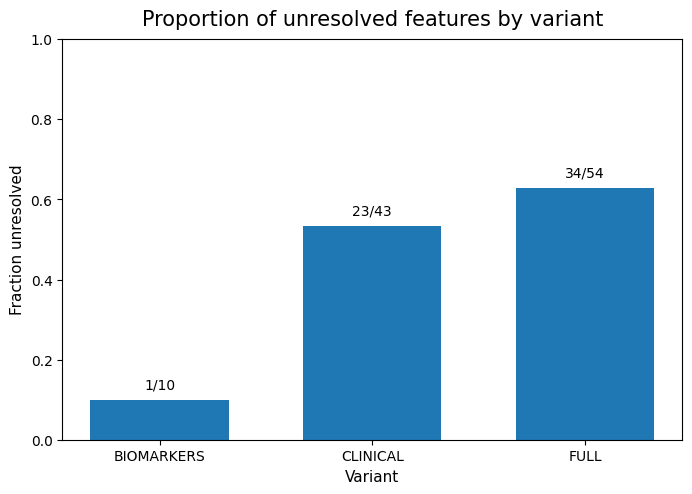

In [10]:


fig, ax = plt.subplots(figsize=(8, 5.2))

ax.bar(
    unresolved_variant_summary["variant"],
    unresolved_variant_summary["pct_unresolved"],
    width=0.65
)

ax.set_ylabel("Fraction unresolved", fontsize=11)
ax.set_xlabel("Variant", fontsize=11)
ax.set_ylim(0, 1.0)
ax.tick_params(axis="both", labelsize=10)
ax.set_title("Proportion of unresolved features by variant", fontsize=15, pad=10)

for i, row in unresolved_variant_summary.iterrows():
    ax.text(
        i,
        row["pct_unresolved"] + 0.02,
        f"{row['n_unresolved']}/{row['n_features_total']}",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.savefig(OUT_DIR / "S18_plot_unresolved_fraction_by_variant.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Plot 2: unresolved reasons by variant

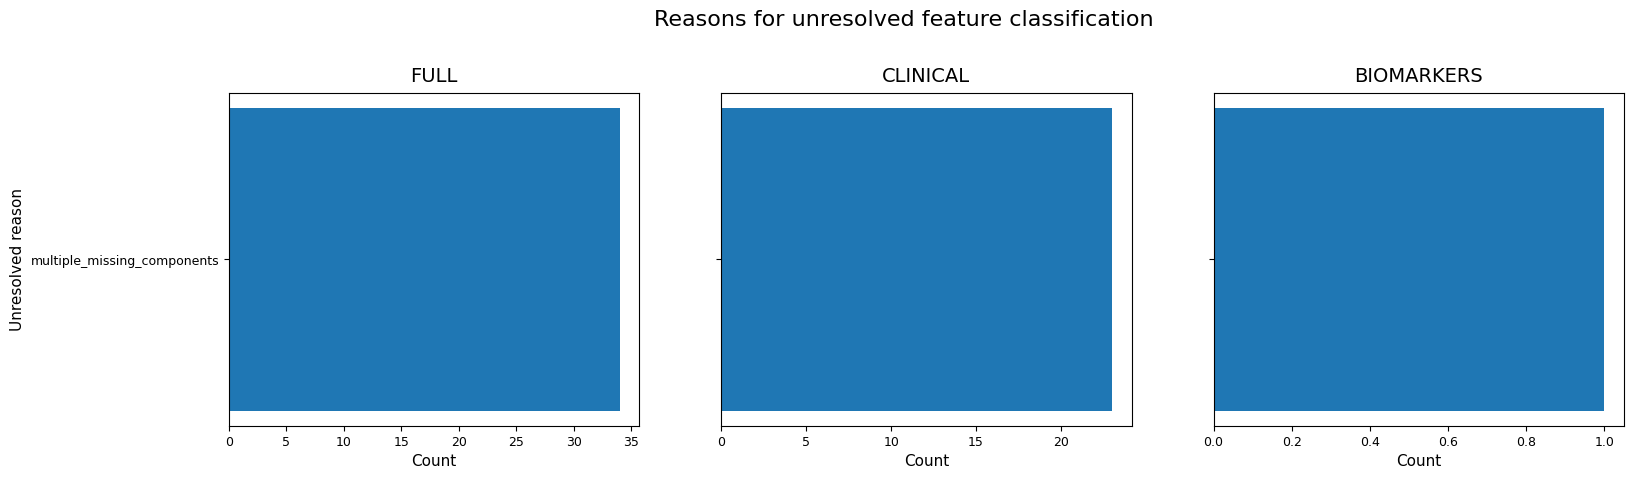

In [11]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
fig.subplots_adjust(top=0.82, bottom=0.18, wspace=0.20)

for ax, variant in zip(axes, VARIANTS):
    sub = unresolved_reason_summary[unresolved_reason_summary["variant"] == variant].copy()

    if sub.empty:
        ax.set_title(variant, fontsize=14, pad=8)
        ax.set_xlabel("Count", fontsize=11)
        ax.set_ylabel("Reason", fontsize=11)
        continue

    sub = sub.sort_values("n_features", ascending=True)
    ax.barh(sub["unresolved_reason"], sub["n_features"])
    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Count", fontsize=11)
    ax.tick_params(axis="both", labelsize=9)

axes[0].set_ylabel("Unresolved reason", fontsize=11)

fig.suptitle("Reasons for unresolved feature classification", fontsize=16, y=0.98)
fig.savefig(OUT_DIR / "S18_plot_unresolved_reasons_by_variant.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

In [12]:
print("Saved outputs:")
for path in sorted(OUT_DIR.glob("S18_*")):
    print(path.name)

Saved outputs:
S18_config_snapshot.json
S18_plot_unresolved_fraction_by_variant.png
S18_plot_unresolved_reasons_by_variant.png
S18_publication_table.csv
S18_unresolved_feature_audit.csv
S18_unresolved_reason_summary.csv
S18_unresolved_reason_summary_wide.csv
S18_unresolved_variant_summary.csv
